# Разработка A/B-тестирования и анализ результатов
Роль – продуктовый аналитик в компании, которая разрабатывает развлекательное приложение с функцией «бесконечной» ленты, как, например, в приложениях с короткими видео. В приложении существует две модели монетизации: первая — ежемесячная платная подписка, которая позволяет пользователям смотреть ленту без рекламы, вторая — демонстрация рекламы для пользователей, которые ещё не оформили подписку.

Команда разработчиков рекомендательных систем создала новый алгоритм рекомендаций, который, по их мнению, будет показывать более интересный контент для каждого пользователя. Задача – помочь рассчитать параметры A/B-теста, который позволит проверить эту гипотезу, и проанализировать его результаты.

## Описание данных

Будем работать с тремя таблицами:

- `sessions_project_history.csv` — таблица с историческими данными по сессиям пользователей на период с 2025-08-15 по 2025-09-23.

- `sessions_project_test_part.csv` — таблица с данными за первый день проведения A/B-теста, то есть за 2025-10-14.

- `sessions_project_test.csv` — таблица с данными за весь период проведения A/B-теста, то есть с 2025-10-14 по 2025-11-02. 

У этих таблиц почти совпадает структура и содержание колонок, различаются лишь периоды наблюдения.

Поля таблиц `sessions_project_history.csv`, `sessions_project_test.csv`, `sessions_project_test_part.csv`:

- `user_id` — идентификатор пользователя;

- `session_id` — идентификатор сессии в приложении;

- `session_date` — дата сессии;

- `session_start_ts` — дата и время начала сессии;

- `install_date` — дата установки приложения;

- `session_number` — порядковый номер сессии для конкретного пользователя;

- `registration_flag` — является ли пользователь зарегистрированным;

- `page_counter` — количество просмотренных страниц во время сессии;

- `region` — регион пользователя;

- `device` — тип устройства пользователя;

- `test_group` — тестовая группа (в таблице с историческими данными этого столбца нет).


## Что нужно сделать
**Задача:** рассчитать параметры теста, оценить корректность его проведения и проанализировать результаты эксперимента.

### 1. Работа с историческими данными (EDA)

#### 1.1. Загрузка исторических данных
На первом этапе поработаем с историческими данными приложения:

- Импортируем библиотеку pandas.

- Считаем и сохраним в датафрейм `sessions_history` CSV-файл с историческими данными о сессиях пользователей `sessions_project_history.csv`.


In [1]:
# необходимые импорты
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats
import statsmodels.stats

In [2]:
sessions_history = pd.read_csv('/datasets/sessions_project_history.csv')

In [3]:
sessions_history.head()

,user_id,session_id,session_date,session_start_ts,install_date,session_number,registration_flag,page_counter,region,device
0,E302123B7000BFE4,F9AF61A0C2023832,2025-08-15,2025-08-15 17:47:35,2025-08-15,1,0,3,CIS,iPhone
1,2530F72E221829FB,85003A206CBDAC6F,2025-08-15,2025-08-15 16:42:14,2025-08-15,1,0,4,MENA,Android
2,876E020A4FC512F5,3677423E49D72DEE,2025-08-15,2025-08-15 12:30:00,2025-08-15,1,0,4,EU,PC
3,2640B349E1D81584,956B45F5915CA225,2025-08-15,2025-08-15 15:31:31,2025-08-15,1,0,4,CIS,Android
4,94E1CBFAEF1F5EE9,83BF0DA35F9F1F40,2025-08-15,2025-08-15 21:33:53,2025-08-15,1,0,3,CIS,Android


In [4]:
sessions_history.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 435924 entries, 0 to 435923
Data columns (total 10 columns):
 #   Column             Non-Null Count   Dtype 
---  ------             --------------   ----- 
 0   user_id            435924 non-null  object
 1   session_id         435924 non-null  object
 2   session_date       435924 non-null  object
 3   session_start_ts   435924 non-null  object
 4   install_date       435924 non-null  object
 5   session_number     435924 non-null  int64 
 6   registration_flag  435924 non-null  int64 
 7   page_counter       435924 non-null  int64 
 8   region             435924 non-null  object
 9   device             435924 non-null  object
dtypes: int64(3), object(7)
memory usage: 33.3+ MB


In [5]:
# преобразуем столбцы с датой в корректный формат
sessions_history['session_date'] = pd.to_datetime(sessions_history['session_date']).dt.date
sessions_history['session_start_ts'] = pd.to_datetime(sessions_history['session_start_ts'])
sessions_history['install_date'] = pd.to_datetime(sessions_history['install_date']).dt.date

sessions_history.head() 

,user_id,session_id,session_date,session_start_ts,install_date,session_number,registration_flag,page_counter,region,device
0,E302123B7000BFE4,F9AF61A0C2023832,2025-08-15,2025-08-15 17:47:35,2025-08-15,1,0,3,CIS,iPhone
1,2530F72E221829FB,85003A206CBDAC6F,2025-08-15,2025-08-15 16:42:14,2025-08-15,1,0,4,MENA,Android
2,876E020A4FC512F5,3677423E49D72DEE,2025-08-15,2025-08-15 12:30:00,2025-08-15,1,0,4,EU,PC
3,2640B349E1D81584,956B45F5915CA225,2025-08-15,2025-08-15 15:31:31,2025-08-15,1,0,4,CIS,Android
4,94E1CBFAEF1F5EE9,83BF0DA35F9F1F40,2025-08-15,2025-08-15 21:33:53,2025-08-15,1,0,3,CIS,Android


#### 1.2. Знакомство с данными
- Для каждого уникального пользователя `user_id` рассчитаем количество уникальных сессий `session_id`.

- Выведем на экран все данные из таблицы `sessions_history` для одного пользователя с наибольшим количеством сессий. Если таких пользователей окажется несколько, выберем любого из них.

- Изучим таблицу для одного пользователя, чтобы лучше понять логику формирования каждого столбца данных.

In [6]:
unique_sessions = sessions_history.groupby('user_id')['session_id'].nunique()
unique_sessions.sort_values(ascending=False)

user_id_max = unique_sessions.idxmax()

sessions_history[sessions_history['user_id'] == user_id_max]

,user_id,session_id,session_date,session_start_ts,install_date,session_number,registration_flag,page_counter,region,device
115558,10E0DEFC1ABDBBE0,B8F0423BBFFCF5DC,2025-08-14,2025-08-14 13:57:39,2025-08-14,1,0,4,CIS,Android
191751,10E0DEFC1ABDBBE0,87CA2FA549473837,2025-08-15,2025-08-15 16:42:10,2025-08-14,2,0,3,CIS,Android
239370,10E0DEFC1ABDBBE0,4ADD8011DCDCE318,2025-08-16,2025-08-16 19:53:21,2025-08-14,3,0,3,CIS,Android
274629,10E0DEFC1ABDBBE0,DF0FD0E09BF1F3D7,2025-08-17,2025-08-17 15:03:43,2025-08-14,4,0,1,CIS,Android
302501,10E0DEFC1ABDBBE0,3C221774B4DE6885,2025-08-18,2025-08-18 17:29:14,2025-08-14,5,0,4,CIS,Android
325557,10E0DEFC1ABDBBE0,031BD7A67048105B,2025-08-19,2025-08-19 13:23:55,2025-08-14,6,0,2,CIS,Android
345336,10E0DEFC1ABDBBE0,FF4315CF4AD4B100,2025-08-20,2025-08-20 19:31:54,2025-08-14,7,0,2,CIS,Android
377532,10E0DEFC1ABDBBE0,4045FEA0747203B4,2025-08-22,2025-08-22 17:54:13,2025-08-14,8,0,2,CIS,Android
403538,10E0DEFC1ABDBBE0,344B086C421C7F37,2025-08-24,2025-08-24 14:46:13,2025-08-14,9,0,2,CIS,Android
414743,10E0DEFC1ABDBBE0,054F20BA371E4C9D,2025-08-25,2025-08-25 18:36:41,2025-08-14,10,0,3,CIS,Android


#### 1.3. Анализ числа регистраций
Одна из важнейших метрик продукта — число зарегистрированных пользователей. Используя исторические данные, визуализируем, как менялось число регистраций в приложении за время его существования (пользователь считается зарегистрированным только в день совершения регистрации). Таким образом, необходимо проанализировать количество зарегистрированных активных пользователей за каждый день без накопления (аналог DAU, но для регистраций пользователей).

- Агрегируем исторические данные и рассчитаем число уникальных пользователей и число зарегистрированных пользователей для каждого дня наблюдения. Будем считать, что у пользователя в течение дня бывает одна сессия максимум и статус регистрации в течение одного дня не может измениться.

- Построим линейные графики общего числа пользователей и общего числа зарегистрированных пользователей по дням, отобразим их на одном графике.

- Построим отдельный линейный график доли зарегистрированных пользователей от всех пользователей по дням.

In [7]:
users_count = (
    sessions_history
    .groupby('session_date')['user_id'] # группируем 
    .nunique() # считаем число уникальных user_id
    .reset_index(name='unique_users')
)

reg_count = (
    sessions_history[sessions_history['registration_flag'] == 1] # отбираем только зарегистрированных пользователей
    .groupby('session_date')['user_id'] # группируем 
    .nunique() # считаем число уникальных user_id среди зарегистированных
    .reset_index(name='registered_users')
)

users = users_count.merge(reg_count)
users

,session_date,unique_users,registered_users
0,2025-08-11,3919,169
1,2025-08-12,6056,336
2,2025-08-13,8489,464
3,2025-08-14,10321,625
4,2025-08-15,14065,840
5,2025-08-16,12205,916
6,2025-08-17,11200,833
7,2025-08-18,10839,860
8,2025-08-19,12118,831
9,2025-08-20,13514,1008


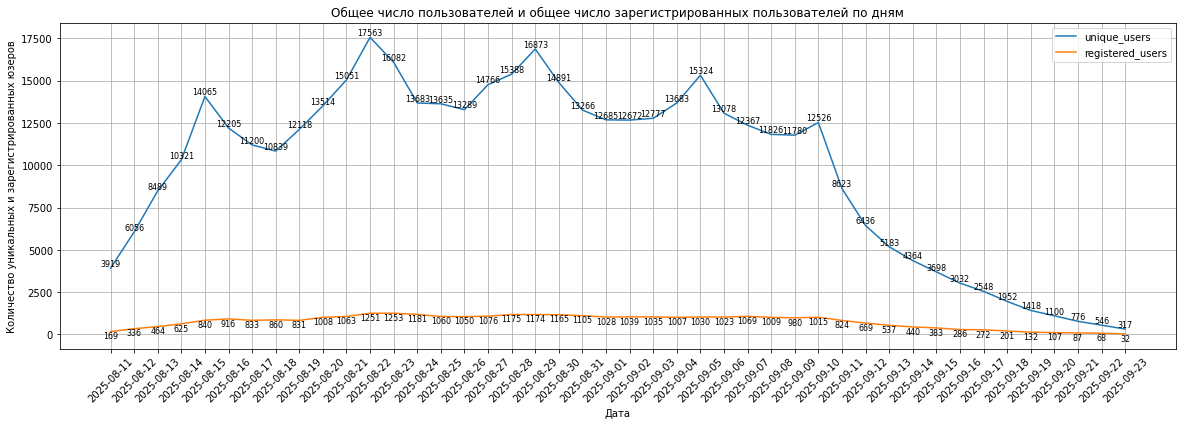

In [8]:
x = users['session_date']
y_a = users['unique_users']
y_b = users['registered_users']

plt.figure(figsize=(20, 6))
plt.plot(x, y_a, label='unique_users')
plt.plot(x, y_b,label='registered_users')

plt.xticks(x, rotation=45) # отображаем в подписях на оси Х каждую дату

# подписи для unique_users
for i, value in enumerate(y_a):
    plt.text(x.iloc[i], value, str(value),
             ha='center', va='bottom', fontsize=8)

# подписи для registered_users
for i, value in enumerate(y_b):
    plt.text(x.iloc[i], value, str(value),
             ha='center', va='top', fontsize=8)


plt.xlabel("Дата")
plt.ylabel("Количество уникальных и зарегистрированных юзеров")
plt.title('Общее число пользователей и общее число зарегистрированных пользователей по дням')
plt.legend()
plt.grid()
plt.show()

По графикам можно заметить, что в данных примерно с 13.08 по 10.09 присутствует сезонность. Пик активности пользователей еженедельно приходится на пятницу, а к воскресенью происходит спад до минимума активных пользователей (в будни – с понедельника по пятницу – активность постепенно повышается, за выходные – с пятницы по воскресенье – снижается). Среди зарегистрированных пользователей наблюдается аналогичный паттерн активности.

С 10.09 наблюдается резкий и очень значительный спад активности – количество активных пользователей за две недели упало почти в 40 раз! Следовало бы выяснить, с чем это связано. Возможно, какие-то технические неполадки в приложении или же пользователи больше не хотят пользоваться приложением?

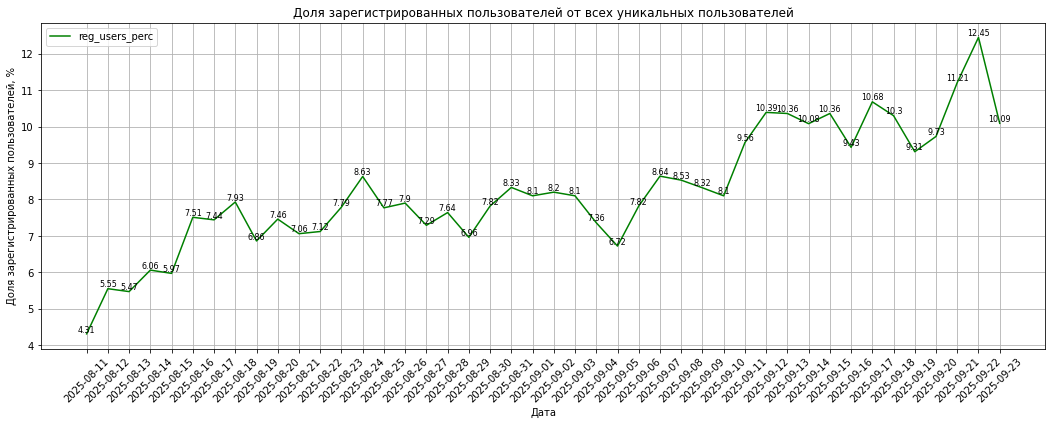

In [9]:
users['reg_users_perc'] = round(100 * users['registered_users'] / users['unique_users'], 2)

x = users['session_date']
y = users['reg_users_perc']

plt.figure(figsize=(18, 6))
plt.plot(x, y, label='reg_users_perc', color='green')

plt.xticks(x, rotation=45) # отображаем в подписях на оси Х каждую дату

# подписи
for i, value in enumerate(y):
    plt.text(x.iloc[i], value, str(value),
             ha='center', va='bottom', fontsize=8)


plt.xlabel("Дата")
plt.ylabel("Доля зарегистрированных пользователей, %")
plt.title('Доля зарегистрированных пользователей от всех уникальных пользователей')
plt.legend()
plt.grid()
plt.show()

In [10]:
users['reg_users_perc'].mean()

8.24340909090909

Доля зарегистрированных пользователей от всех активных пользователей изменяется в диапазоне примерно от 4.3% до 12,45%. Разброс у показателя сильный. При этом это довольно малая величина – в среднем только около 8.2% пользователей являются зарегистрированными. Однако по графику заметен положительный тренд на рост – доля зарегистрированных пользователей явно растет со временем.

#### 1.4. Анализ числа просмотренных страниц
Другая важная метрика продукта — число просмотренных страниц в приложении. Чем больше страниц просмотрено, тем сильнее пользователь увлечён контентом, а значит, выше шансы, что он зарегистрируется и оплатит подписку.

Проанализируем число просмотренных страниц во время первых сессий пользователей. Найдем количество первых сессий для каждого значения количества просмотренных страниц.


In [11]:
first_sessions = sessions_history[sessions_history['session_number'] == 1].groupby('page_counter')['session_number'].count()
first_sessions

page_counter
1     8978
2    32494
3    50939
4    32739
5     8075
6      777
7       37
Name: session_number, dtype: int64

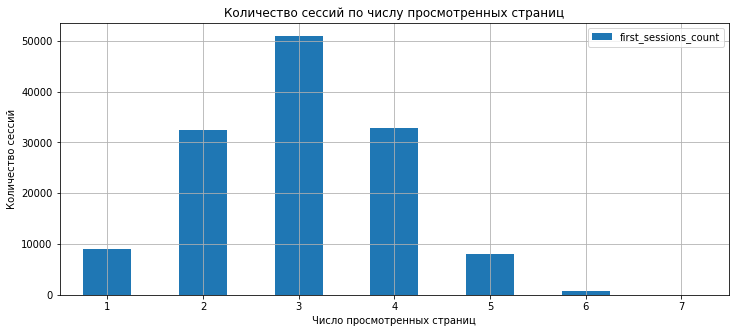

In [12]:
plt.figure(figsize=(12, 5))

first_sessions.plot(kind='bar', label='first_sessions_count', rot=0)

plt.xlabel("Число просмотренных страниц")
plt.ylabel("Количество сессий")
plt.title('Количество сессий по числу просмотренных страниц')
plt.legend()
plt.grid()
plt.show()

На большинство первых сессий приходится 3 просмотренные страницы.

#### 1.5. Доля пользователей, просмотревших более четырёх страниц
Продуктовая команда продукта считает, что первые сессии, в рамках которых пользователь просмотрел 4 и более страниц, говорят об удовлетворённости контентом и алгоритмами рекомендаций. Этот показатель является важной прокси-метрикой для продукта.

- В датафрейме `sessions_history` создадим дополнительный столбец `good_session`. В него войдёт значение `1`, если за одну сессию было просмотрено 4 и более страниц, и значение `0`, если было просмотрено меньше.

- Построим график со средним значением доли успешных первых сессий от всех первых сессий пользователей, визуализируем данные по дням за весь период наблюдения.

In [13]:
sessions_history['good_session'] = 0
sessions_history.loc[sessions_history['page_counter'] >= 4, 'good_session'] = 1

display(sessions_history.head(), sessions_history.tail())

,user_id,session_id,session_date,session_start_ts,install_date,session_number,registration_flag,page_counter,region,device,good_session
0,E302123B7000BFE4,F9AF61A0C2023832,2025-08-15,2025-08-15 17:47:35,2025-08-15,1,0,3,CIS,iPhone,0
1,2530F72E221829FB,85003A206CBDAC6F,2025-08-15,2025-08-15 16:42:14,2025-08-15,1,0,4,MENA,Android,1
2,876E020A4FC512F5,3677423E49D72DEE,2025-08-15,2025-08-15 12:30:00,2025-08-15,1,0,4,EU,PC,1
3,2640B349E1D81584,956B45F5915CA225,2025-08-15,2025-08-15 15:31:31,2025-08-15,1,0,4,CIS,Android,1
4,94E1CBFAEF1F5EE9,83BF0DA35F9F1F40,2025-08-15,2025-08-15 21:33:53,2025-08-15,1,0,3,CIS,Android,0


,user_id,session_id,session_date,session_start_ts,install_date,session_number,registration_flag,page_counter,region,device,good_session
435919,769BC199AF26FEF8,914903B51D69C5EA,2025-09-17,2025-09-17 21:33:57,2025-09-04,3,1,3,CIS,PC,0
435920,599DED39F3CD2ADE,66ADBE343C94DCDA,2025-09-17,2025-09-17 17:11:46,2025-09-04,4,0,4,MENA,iPhone,1
435921,1FA20C4BC94E64B2,C4CCD7E81733665F,2025-09-17,2025-09-17 19:36:55,2025-09-04,4,0,4,CIS,Android,1
435922,88E5FC3016A7A0AD,6834FB4914B56200,2025-09-17,2025-09-17 22:13:33,2025-09-04,5,0,4,MENA,PC,1
435923,5CC144801F7B0D1D,8CC9E67AFF5D9CA8,2025-09-17,2025-09-17 15:23:46,2025-09-04,3,0,2,MENA,iPhone,0


In [14]:
first_sess = (
    sessions_history[sessions_history['session_number'] == 1]
    .groupby('session_date')['session_id']
    .nunique()
    .reset_index(name='first_sess_count')
)

good_sess = (
    sessions_history[(sessions_history['good_session'] == 1) & (sessions_history['session_number'] == 1)]
    .groupby('session_date')['session_id']
    .nunique()
    .reset_index(name='good_sess_count')
)

sessions = first_sess.merge(good_sess)

sessions['good_sess_perc'] = round(100 * sessions['good_sess_count'] / sessions['first_sess_count'], 2)
sessions

,session_date,first_sess_count,good_sess_count,good_sess_perc
0,2025-08-11,3919,1226,31.28
1,2025-08-12,4106,1225,29.83
2,2025-08-13,5087,1561,30.69
3,2025-08-14,5456,1741,31.91
4,2025-08-15,7801,2427,31.11
5,2025-08-16,3787,1168,30.84
6,2025-08-17,2978,951,31.93
7,2025-08-18,3079,964,31.31
8,2025-08-19,4412,1387,31.44
9,2025-08-20,5215,1612,30.91


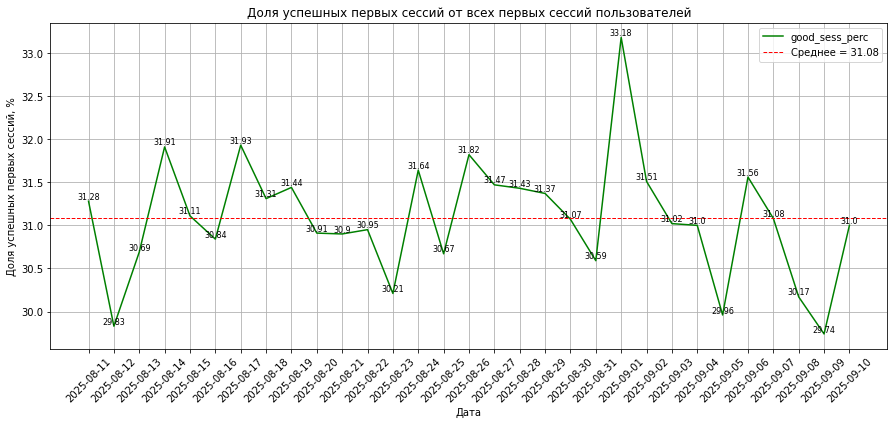

In [15]:
x = sessions['session_date']
y = sessions['good_sess_perc']

plt.figure(figsize=(15, 6))
plt.plot(x, y, label='good_sess_perc', color='green')

plt.xticks(x, rotation=45) # отображаем в подписях на оси Х каждую дату

# подписи
for i, value in enumerate(y):
    plt.text(x.iloc[i], value, str(value),
             ha='center', va='bottom', fontsize=8)

# среднее
mean_value = sessions['good_sess_perc'].mean()
plt.axhline(mean_value, color='red', linestyle='--', linewidth=1,
            label=f'Среднее = {mean_value:.2f}')

plt.xlabel("Дата")
plt.ylabel("Доля успешных первых сессий, %")
plt.title('Доля успешных первых сессий от всех первых сессий пользователей')
plt.legend()
plt.grid()
plt.show()

Среднее значение доли успешных первых сессий от всех первых сессий пользователей составляет 31.08%. Значения доли варьируются от 29.74% до 33.18%.

### 2. Подготовка к тесту
При планировании теста проделаем несколько важных шагов:

- Определимся с целевой метрикой.

- Рассчитаем необходимый размер выборки.

- Исходя из текущих значений трафика рассчитаем необходимую длительность проведения теста.

#### 2.1. Расчёт размера выборки
Рассчитаем необходимое для эксперимента количество пользователей.

- Уровень значимости — 0.05.

- Вероятность ошибки второго рода — 0.2.

- Мощность теста – 0.8.

- Минимальный детектируемый эффект (MDE) — 3%.

При расчете размера выборки будем использовать метод `solve_power()` из класса `power.NormalIndPower` модуля `statsmodels.stats`.


In [16]:
from statsmodels.stats.power import NormalIndPower
from statsmodels.stats.proportion import proportion_effectsize

# Задаем параметры:
alpha = 0.05  # Уровень значимости
beta = 0.2  # Ошибка второго рода
power = 1 - beta # Мощность теста
p = 0.3 # Базовый уровень доли
mde = p * 0.03  # Минимальный детектируемый эффект
effect_size = proportion_effectsize(p, p + mde)

# Инициализируем класс NormalIndPower
power_analysis = NormalIndPower()

# Расчёт размера выборки
sample_size = power_analysis.solve_power(
    effect_size = effect_size,
    power = power,
    alpha = alpha,
    ratio = 1 # Равномерное распределение выборок
)

print(f"Необходимый размер выборки для каждой группы: {int(sample_size)}")

Необходимый размер выборки для каждой группы: 41040


#### 2.2. Расчёт длительности A/B-теста

Используем данные о количестве пользователей в каждой выборке и среднем количестве пользователей приложения. Рассчитаем длительность теста, разделив одно на другое.

- Рассчитаем среднее количество уникальных пользователей приложения в день.

- Определим длительность теста исходя из рассчитанного значения размера выборок и среднего дневного трафика приложения.

In [17]:
from math import ceil

# Среднее количество пользователей приложения в день по историческим данным
avg_daily_users = users['unique_users'].mean()

# Рассчитываем длительность теста в днях как отношение размера выборки к среднему числу пользователей
test_duration = ceil(2 * sample_size / avg_daily_users)

print(f"Рассчитанная длительность A/B-теста при текущем уровене трафика в {round(avg_daily_users, 2)} пользователей в день составит {test_duration} дней")

Рассчитанная длительность A/B-теста при текущем уровене трафика в 9907.36 пользователей в день составит 9 дней


### 3. Мониторинг А/В-теста

#### 3.1. Проверка распределения пользователей

A/B-тест успешно запущен, и уже доступны данные за первые три дня. На этом этапе нужно убедиться, что всё идёт хорошо: пользователи разделены правильным образом, а интересующие вас метрики корректно считаются.

- Считаем и сохраним в датафрейм `sessions_test_part` CSV-файл с историческими данными о сессиях пользователей `sessions_project_test_part.csv`.

- Рассчитаем количество уникальных пользователей в каждой из экспериментальных групп для одного дня наблюдения.

- Рассчитаем и выведем на экран процентную разницу в количестве пользователей в группах A и B. Построим визуализацию, на которой будет видно возможное различие двух групп.

Для расчёта процентной разницы воспользуемся формулой:
$$P = 100 \cdot  \frac{|A − B|}{A}$$

In [18]:
sessions_test_part = pd.read_csv('/datasets/sessions_project_test_part.csv')

In [19]:
sessions_test_part.head()

,user_id,session_id,session_date,session_start_ts,install_date,session_number,registration_flag,page_counter,region,device,test_group
0,3404844B53442747,B4901323BD537E45,2025-10-14,2025-10-14 19:28:49,2025-10-14,1,0,3,CIS,Android,B
1,3A2BF4D364E62D89,216FC619308F8788,2025-10-14,2025-10-14 21:11:04,2025-10-14,1,0,3,MENA,iPhone,A
2,79CDAE11E32B1597,EDFCE4AC1A504074,2025-10-14,2025-10-14 21:44:03,2025-10-14,1,0,3,CIS,iPhone,A
3,D6AF8D78297A931F,CF0AC0EEDE92C690,2025-10-14,2025-10-14 19:07:55,2025-10-14,1,0,4,CIS,PC,A
4,37E0CE723AE568E0,2E6ED45E8C86C4E9,2025-10-14,2025-10-14 15:39:44,2025-10-14,1,0,3,CIS,Mac,B


In [20]:
users_per_group = sessions_test_part.groupby('test_group')['user_id'].nunique()
users_per_group

test_group
A    1477
B    1466
Name: user_id, dtype: int64

In [21]:
users_A = 100 * users_per_group.iloc[0] / users_per_group.sum()
users_B = 100 * users_per_group.iloc[1] / users_per_group.sum()

print(users_A, users_B)

50.18688413183826 49.81311586816174


In [22]:
perc_diff = 100 * abs(users_A - users_B) / users_A
perc_diff

0.7447528774543066

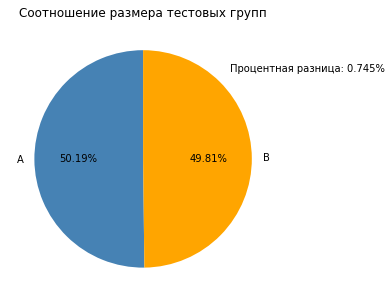

In [23]:
plt.figure(figsize=(10, 5))

pd.Series({'A': users_A, 'B': users_B}).plot(
    kind='pie',
    title='Соотношение размера тестовых групп',
    autopct='%.2f%%',
    ylabel='', 
    colors=['steelblue', 'orange'],
    startangle=90
)

plt.text(0.8, 0.8, f'Процентная разница: {round(perc_diff, 3)}%')

plt.show()

Группа В получилась чуть меньше группы А (процентная разница составляет 0.745%), однако такой небольшой разницей можно пренебречь.

#### 3.2. Проверка пересечений пользователей
Помимо проверки равенства количества пользователей в группах, полезно убедиться в том, что группы независимы. Для этого нужно убедиться, что никто из пользователей случайно не попал в обе группы одновременно.

- Рассчитайте количество пользователей, которые встречаются одновременно в группах A и B, или убедитесь, что таких нет.

In [24]:
group_A = sessions_test_part[sessions_test_part['test_group'] == 'A']['user_id']
group_B = sessions_test_part[sessions_test_part['test_group'] == 'B']['user_id']

intersection = list(set(group_A) & set(group_B))
intersection

[]

Пользователей, которые встречаются одновременно в группах A и B, не обнаружено.

#### 3.3. Равномерность разделения пользователей по устройствам
Полезно также убедиться в том, что пользователи равномерно распределены по всем доступным категориальным переменным — типам устройств и регионам.

Построим две диаграммы:

- доля каждого типа устройства для пользователей из группы A,

- доля каждого типа устройства для пользователей из группы B.


In [25]:
device_share = (
    sessions_test_part
    .groupby(['test_group', 'device'])['user_id'] # группируем по test_group и device
    .nunique() # считаем уникальных пользователей по каждому девайсу в каждой группе
)

device_share = (
    device_share
    .groupby('test_group') # перегруппируем только по test_group
    .apply(lambda x: x / x.sum() * 100) # считаем доли каждого девайса внутри каждой группы
    .reset_index(name='share')
)

device_share

,test_group,device,share
0,A,Android,44.414353
1,A,Mac,10.561950
2,A,PC,24.983074
3,A,iPhone,20.040623
4,B,Android,45.566166
5,B,Mac,10.095498
6,B,PC,25.989086
7,B,iPhone,18.349250


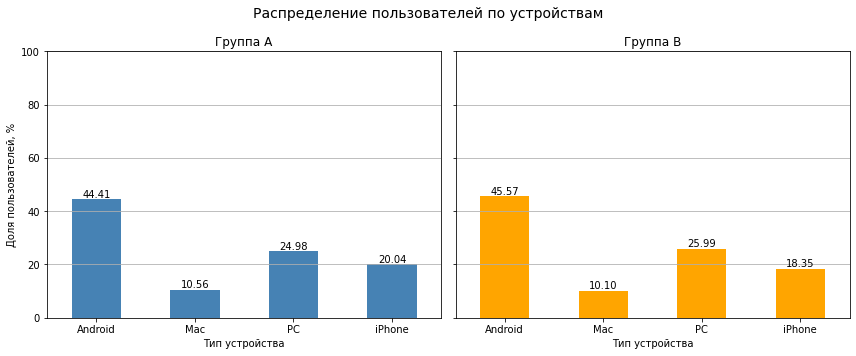

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

# группа A
ax0 = device_share[device_share['test_group'] == 'A'] \
    .set_index('device')['share'] \
    .plot(kind='bar', ax=axes[0], rot=0, color='steelblue')

# подписи
for p in ax0.patches:
    axes[0].text(
        p.get_x() + p.get_width()/2,
        p.get_height(),
        f'{p.get_height():.2f}',
        ha='center',
        va='bottom'
    )
    
axes[0].set_title('Группа A')
axes[0].set_xlabel('Тип устройства')
axes[0].set_ylabel('Доля пользователей, %')
axes[0].set_ylim(0, 100)
axes[0].grid(axis='y')

# группа B
ax1 = device_share[device_share['test_group'] == 'B'] \
    .set_index('device')['share'] \
    .plot(kind='bar', ax=axes[1], rot=0, color='orange')

# подписи
for p in ax1.patches:
    axes[1].text(
        p.get_x() + p.get_width()/2,
        p.get_height(),
        f'{p.get_height():.2f}',
        ha='center',
        va='bottom'
    )
    
axes[1].set_title('Группа B')
axes[1].set_xlabel('Тип устройства')
axes[1].set_ylim(0, 100)
axes[1].grid(axis='y')


plt.suptitle('Распределение пользователей по устройствам', fontsize=14)
plt.tight_layout()
plt.show()

По данным графикам видно, что пользователи распределены по устройствам примерно одинаково в обеих группах. 

#### 3.4. Равномерность распределения пользователей по регионам
Теперь убедимся, что пользователи равномерно распределены по регионам.

Построим две диаграммы:

- доля каждого региона для пользователей из группы A,

- доля каждого региона для пользователей из группы B.


In [27]:
region_share = (
    sessions_test_part
    .groupby(['test_group', 'region'])['user_id'] # группируем по test_group и device
    .nunique() # считаем уникальных пользователей по каждому региону в каждой группе
)

region_share = (
    region_share
    .groupby('test_group') # перегруппируем только по test_group
    .apply(lambda x: x / x.sum() * 100) # считаем доли каждого региона внутри каждой группы
    .reset_index(name='share')
)

region_share

,test_group,region,share
0,A,CIS,43.601896
1,A,EU,15.165877
2,A,MENA,41.232227
3,B,CIS,43.997271
4,B,EU,14.802183
5,B,MENA,41.200546


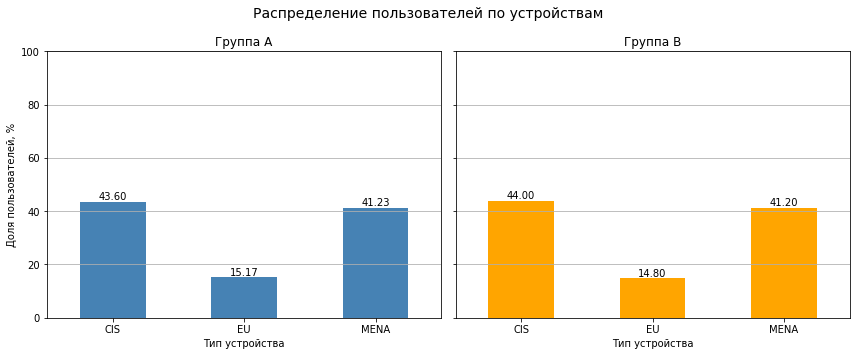

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

# группа A
ax0 = region_share[region_share['test_group'] == 'A'] \
    .set_index('region')['share'] \
    .plot(kind='bar', ax=axes[0], rot=0, color='steelblue')

# подписи
for p in ax0.patches:
    axes[0].text(
        p.get_x() + p.get_width()/2,
        p.get_height(),
        f'{p.get_height():.2f}',
        ha='center',
        va='bottom'
    )
    
axes[0].set_title('Группа A')
axes[0].set_xlabel('Тип устройства')
axes[0].set_ylabel('Доля пользователей, %')
axes[0].set_ylim(0, 100)
axes[0].grid(axis='y')

# группа B
ax1 = region_share[region_share['test_group'] == 'B'] \
    .set_index('region')['share'] \
    .plot(kind='bar', ax=axes[1], rot=0, color='orange')

# подписи
for p in ax1.patches:
    axes[1].text(
        p.get_x() + p.get_width()/2,
        p.get_height(),
        f'{p.get_height():.2f}',
        ha='center',
        va='bottom'
    )
    
axes[1].set_title('Группа B')
axes[1].set_xlabel('Тип устройства')
axes[1].set_ylim(0, 100)
axes[1].grid(axis='y')


plt.suptitle('Распределение пользователей по устройствам', fontsize=14)
plt.tight_layout()
plt.show()

По данным графикам видно, что пользователи распределены по регионам так же примерно одинаково в обеих группах.

#### 3.5. Вывод после проверки A/B-теста


**Выводы:**

Различие в количестве пользователей в двух группах было обнаружено незначительное – в группу А вошло 1477 пользователей, а в группу В – 1466 пользователей. Процентное соотношение – 50.19% (А) к 49.81% (В). Процентная разница составила 0.745%.

Выборки являются независимыми, пересечения пользователей из тестовой и контрольной групп обнаружено не было.

Равномерное распределение пользователей тестовой и контрольной групп по категориальным переменным – устройствам и регионам – сохраняется, пользователи в обеих группах по категориям распределены примерно одинаково.

**Заключение:** А/В-тест проходит корректно, значительных нарушений не наблюдается.

### 4. Проверка результатов A/B-теста

A/B-тест завершён, и у нас есть результаты за все дни проведения эксперимента. Необходимо убедиться в корректности теста и верно интерпретировать результаты.

#### 4.1. Получение результатов теста и подсчёт основной метрики

- Считаем и сохраним в датафрейм `sessions_test` CSV-файл с историческими данными о сессиях пользователей `sessions_project_test.csv`.

- В датафрейме `sessions_test` создадим дополнительный столбец `good_session`. В него войдёт значение `1`, если за одну сессию было просмотрено 4 и более страниц, и значение `0`, если просмотрено меньше.

In [29]:
sessions_test = pd.read_csv('/datasets/sessions_project_test.csv')

In [30]:
sessions_test['good_session'] = 0
sessions_test.loc[sessions_test['page_counter'] >= 4, 'good_session'] = 1

display(sessions_test.head(), sessions_test.tail())

,user_id,session_id,session_date,session_start_ts,install_date,session_number,registration_flag,page_counter,region,device,test_group,good_session
0,6DAE3B3654DA738E,C69249E26E58F6E2,2025-10-26,2025-10-26 18:15:05,2025-10-16,3,0,3,MENA,Android,A,0
1,0A3FE5D1DD59110A,66D66D7C9F5181B7,2025-10-21,2025-10-21 17:04:53,2025-10-15,2,1,2,CIS,Android,B,0
2,2041F1D7AA740B88,50DE51D42215E74C,2025-10-23,2025-10-23 17:39:29,2025-10-19,3,0,2,MENA,Android,A,0
3,43D7585009168086,5763C0C353C22263,2025-10-24,2025-10-24 15:01:57,2025-10-18,4,0,1,CIS,iPhone,B,0
4,15AD68B14D62D88C,B1AD09F93C1053BC,2025-10-17,2025-10-17 17:34:39,2025-10-17,1,0,2,MENA,Android,B,0


,user_id,session_id,session_date,session_start_ts,install_date,session_number,registration_flag,page_counter,region,device,test_group,good_session
100000,CF77C27B238C1BE3,0F7BC9B33685377C,2025-10-22,2025-10-22 19:01:50,2025-10-20,3,0,3,MENA,Android,A,0
100001,D7ED66C581409AC2,26C4475005E70F47,2025-10-17,2025-10-17 22:12:38,2025-10-17,1,0,5,CIS,PC,A,1
100002,E7EA2D51238020C6,9B9CDE6A612CBD73,2025-10-24,2025-10-24 14:54:07,2025-10-14,2,0,3,MENA,PC,B,0
100003,8A6FEFD7F34C5DA1,37291EC27106EF9D,2025-10-18,2025-10-18 00:05:10,2025-10-14,3,0,4,EU,Android,B,1
100004,EE2CA3C8481A0DE8,A4C833633CD4412E,2025-10-23,2025-10-23 10:02:27,2025-10-19,2,0,2,MENA,Android,B,0


#### 4.2 Формулировка нулевой и альтернативной гипотез. Определение целевой, прокси- и барьерных метрик


**Ключевая метрика:**
Цель нового алгоритма – повышение вовлеченности пользователей в контент, увеличение проводимого в приложении времени, т.е. увеличение числа просмотренных страниц. Ключевой метрикой будет **доля успешных первых сессий** (поле good_session).

**Формулировка гипотез:**
* Н0: доля успешных первых сессий в группе А = доле успешных первых сессий в группе В
* Н1: доля успешных первых сессий в группе А < доли успешных первых сессий в группе В

Т.к. нам важно проверить, улучшает ли новый алгорим метрику (стоит ли его внедрять, или же он не оказывает положительного эффекта на метрику, и тогда затраты на внедрение не обоснованы), то будем проверять односторонюю альтернативную гипотезу (А < В).

**Прокси-метрики:** 
Возможными прокси-метриками в данном эксперименте могли бы быть: 
* Среднее количество просмотренных страниц на пользователя (поле page_counter) – рост этой метрики должен предвещать ростключевой метрики.
* Доля регистраций – рост числа регистраций может говорить о том, что пользователям нравится новая рекомендательная система.
* Доля оформленных подписок – пользователи могут начать охотнее оформлять подписки на приложение, чтобы проводить больше времени за просмотром видео без рекламы.

**Барьерные метрики:** 
Барьерными метриками в данном эксперименте могли бы быть:
* Доля активных пользователей в день / Доля повторных заходов в приложение – если пользователи не возвращаются в приложение, вероятно, оно перестало им нравиться или же они сталкиваются с какими-то техническими проблемами в новой версии приложения.
* Число жалоб в поддержку приложения – если что-то не будет работать, то может увеличиться число обращений.
* Снижение числа оформленных подписок / Снижение количества показанной/просмотренной пользователями рекламы – если пользователей что-то не устраивает в новой версии, они перестанут пользоваться продуктом, и из-за этого снизится кол-во просмотренной рекламы и оформленных подписок, что негативно скажется на доходах от монетизации приложения.

#### 4.3. Сравнение доли успешных первых сессий

Перейдем к анализу ключевой метрики — доле успешных первых сессий.

Используем созданный на первом шаге задания столбец `good_session` и рассчитаем долю успешных первых сессий для выборок A и B, а также разницу в этом показателе.

In [31]:
sessions_per_group_test = sessions_test[sessions_test['session_number'] == 1].groupby('test_group')['session_id'].nunique()
sessions_per_group_test

test_group
A    15162
B    15416
Name: session_id, dtype: int64

In [32]:
sessions_A_test = 100 * sessions_per_group_test.iloc[0] / sessions_per_group_test.sum()
sessions_B_test = 100 * sessions_per_group_test.iloc[1] / sessions_per_group_test.sum()

perc_diff_test_total = 100 * abs(sessions_A_test - sessions_B_test) / sessions_A_test

print(sessions_A_test, sessions_B_test, perc_diff_test_total)

49.584668716070375 50.415331283929625 1.6752407334124875


In [33]:
good_sess_test = (
    sessions_test[sessions_test['session_number'] == 1]
    .groupby('test_group')['good_session']
    .sum()
)
good_sess_test

test_group
A    4787
B    4851
Name: good_session, dtype: int64

In [34]:
good_sess_share_A = 100 * good_sess_test.iloc[0]/sessions_per_group_test.iloc[0]
good_sess_share_B = 100 * good_sess_test.iloc[1]/sessions_per_group_test.iloc[1]

print(f'Доля успешных сессий в группе А = {round(good_sess_share_A, 4)}%, доля успешных сессий в группе В = {round(good_sess_share_B, 4)}%')

Доля успешных сессий в группе А = 31.5724%, доля успешных сессий в группе В = 31.4673%


In [35]:
perc_diff_test = 100 * abs(good_sess_share_A - good_sess_share_B) / good_sess_share_A

print(f'Процентная разница = {round(perc_diff_test, 4)}%')

Процентная разница = 0.3327%


#### 4.4. Насколько статистически значимо изменение ключевой метрики

На предыдущем шаге мы убедились, что доли успешных первых сессий в тестовой и контрольной выборках близки, но делать выводы только на основе этого значения будет некорректно. Для принятия решения всегда необходимо отвечать на вопрос: является ли это изменение статистически значимым.

- Используя статистический тест, рассчитаем, является ли изменение в метрике доли успешных первых сессий статистически значимым.

- Определим значение p-value и сделаем выводы о статистической значимости.

In [36]:
from statsmodels.stats.proportion import proportions_ztest

# размер группы A
n_a = sessions_per_group_test.iloc[0]

# размер группы B
n_b = sessions_per_group_test.iloc[1]

# количество успехов в группе A
m_a = good_sess_test.iloc[0]

# количество успехов в группе B
m_b = good_sess_test.iloc[1]

# доли успехов для каждой группы
p_a, p_b = m_a/n_a, m_b/n_b 

# проверка предпосылки о достаточном количестве данных
if (p_a*n_a > 10)and((1-p_a)*n_a > 10)and(p_b*n_b > 10)and((1-p_b)*n_b > 10): 
    print('Предпосылка о достаточном количестве данных выполняется.')
else:
    print('Предпосылка о достаточном количестве данных НЕ выполняется!')

alpha = 0.05 # уровень значимости

# Z-тест пропорций
stat_ztest, p_value_ztest = proportions_ztest( 
    [m_a, m_b],
    [n_a, n_b],
    alternative='smaller'
)

# p-value 
print(f'pvalue={p_value_ztest}') 

if p_value_ztest > alpha:
    print('Нулевая гипотеза находит подтверждение. Не можем отвергнуть Н0!')
else:
    print('Нулевая гипотеза не находит подтверждения! Можем отвергнуть Н0.')

Предпосылка о достаточном количестве данных выполняется.
pvalue=0.5783523649187868
Нулевая гипотеза находит подтверждение. Не можем отвергнуть Н0!


#### 4.5. Вывод по результатам A/B-эксперимента


**Выводы:**

Количество задействованных в эксперименте пользователей составило 30578 (15162 в группе А и 15416 в группе В). Процентное соотношение пользователей в группах – 49.58% в группе А и 50.42% в группе В (процентная разница 1.675%).
Необходимый размер выборки для каждой группы составил 41040. Ежедневный трафик в приложении – 9907.36 пользователей в день. Необходимая минимальная длительность эксперимента – 9 дней. Ключевой метрикой эксперимента была выбрана доля успешных первых сессий пользователей.

Внедрение нового алгоритма рекомендаций на рост ключевой метрики повлияло отрицательно – ключевая метрика немного снизилась (доля успешных сессий в группе А – 31.57%, в группе В – 31.47%, процентная разница – 0.3327%).

Значение p-value для оценки статистической значимости выявленного эффекта получилось равным 0.5783, что больше установленного уровня значимости в 0.05. На этом основании мы не смогли отвергнуть нулевую гипотезу о том, что доли успешных сессий в обеих группах равны. Альтернативную гипотезу о том, что в группе В доля успешных сессий больше, чем в группе А, пришлось отклонить.

По итогам проведенного А/В-теста можно сделать вывод, что внедрять нововведение в приложение не стоит, так как значимого положительного эффекта от нововведений в данном эксперименте обнаружить не удалось.